# Ejercicio 1.10

Simulación de lanzar 1000 monedas justas, 10 veces cada una. Consideramos tres monedas:

- $c_1$: la primera que lanzo
- $c_{rand}$: una elegida al azar
- $c_{min}$: la que sacó menos caras (si hay empate, la primera)

Y comparamos la fracción de caras de cada una ($\nu_1, \nu_{rand}, \nu_{min}$) con la cota de Hoeffding.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N = 10        # lanzamientos por moneda
n_coins = 1000
mu = 0.5      # es una moneda justa
seed = 42

### (a)

Como las tres monedas son justas, $\mu = 0.5$ en los tres casos. No importa cómo se elija la moneda: la probabilidad real de cara siempre es 0.5. Lo que cambia es qué tan lejos queda $\nu$ de ese 0.5.

### (b)

Consideramos el experimento (lanzar las 1000 monedas) y obtenemos las tres fracciones.

In [2]:
def experimento(rng):
    flips = rng.integers(0, 2, size=(n_coins, N))   # 1 = cara
    nu = flips.mean(axis=1)                          # fraccion de caras de cada moneda
    nu1 = nu[0]
    nurand = nu[rng.integers(n_coins)]
    numin = nu.min()
    return nu1, nurand, numin

rng = np.random.default_rng(seed)
experimento(rng)

(np.float64(0.4), np.float64(0.8), np.float64(0.1))

Ahora repetimos 100000 veces.

In [3]:
def simular(n_exp, batch=2000, seed=seed):
    rng = np.random.default_rng(seed)
    nu1 = np.empty(n_exp)
    nurand = np.empty(n_exp)
    numin = np.empty(n_exp)
    i = 0
    while i < n_exp:
        b = min(batch, n_exp - i)
        flips = rng.integers(0, 2, size=(b, n_coins, N), dtype=np.int8)
        nu = flips.sum(axis=2) / N
        nu1[i:i+b] = nu[:, 0]
        idx = rng.integers(n_coins, size=b)
        nurand[i:i+b] = nu[np.arange(b), idx]
        numin[i:i+b] = nu.min(axis=1)
        i += b
    return nu1, nurand, numin

nu1, nurand, numin = simular(100000)

print("promedios:")
print("nu1   =", nu1.mean())
print("nurand=", nurand.mean())
print("numin =", numin.mean())

promedios:
nu1   = 0.49993
nurand= 0.49987299999999996
numin = 0.037791


Los promedios de $\nu_1$ y $\nu_{rand}$ dan cerca de 0.5, pero $\nu_{min}$ da como 0.04. Tiene sentido porque entre 1000 monedas casi siempre alguna sale con casi nada de caras.

Histogramas:

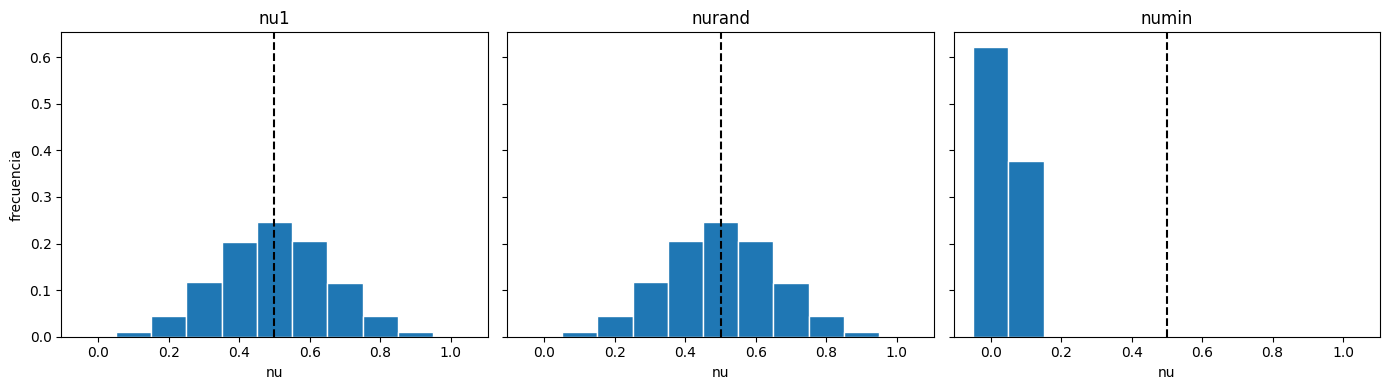

In [4]:
bins = np.arange(-0.05, 1.15, 0.1)
fig, ax = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for a, d, t in zip(ax, [nu1, nurand, numin], ["nu1", "nurand", "numin"]):
    a.hist(d, bins=bins, weights=np.ones(len(d))/len(d), edgecolor="white")
    a.axvline(0.5, color="k", ls="--")
    a.set_title(t)
    a.set_xlabel("nu")
ax[0].set_ylabel("frecuencia")
plt.tight_layout()
plt.show()

Se ve que nu1 y nurand quedan casi iguales (una binomial centrada en 0.5) y numin está concentrado en 0 y 0.1.

### (c)

Estimo $P[|\nu - \mu| > \epsilon]$ contando la fracción de veces que pasa, y graficamos junto a la cota $2e^{-2\epsilon^2 N}$.

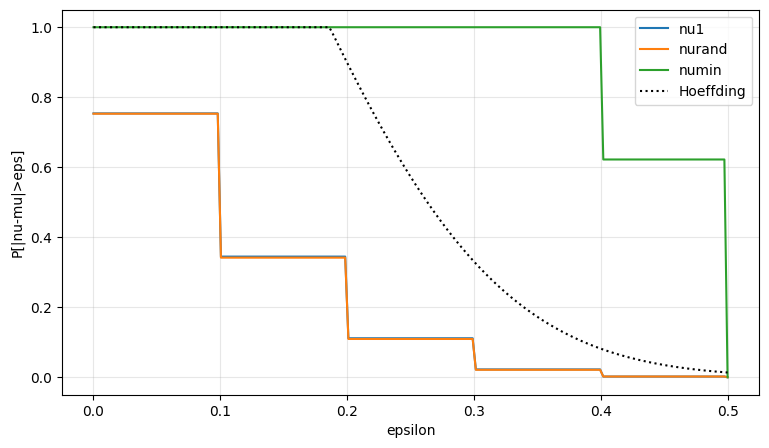

In [5]:
def prob_cola(v, eps):
    dev = np.abs(v - mu)
    return np.array([(dev > e).mean() for e in eps])

eps = np.linspace(0, 0.5, 200)
bound = np.minimum(2*np.exp(-2*eps**2*N), 1)

p1 = prob_cola(nu1, eps)
pr = prob_cola(nurand, eps)
pm = prob_cola(numin, eps)

plt.figure(figsize=(9, 5))
plt.plot(eps, p1, label="nu1")
plt.plot(eps, pr, label="nurand")
plt.plot(eps, pm, label="numin")
plt.plot(eps, bound, "k:", label="Hoeffding")
plt.xlabel("epsilon")
plt.ylabel("P[|nu-mu|>eps]")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Igual pero en escala logarítmica para ver mejor cuánto se pasa numin.

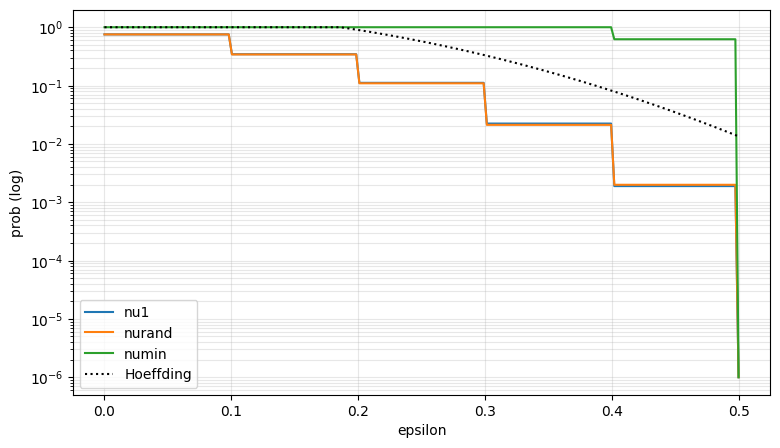

In [6]:
plt.figure(figsize=(9, 5))
plt.semilogy(eps, np.clip(p1, 1e-6, 1), label="nu1")
plt.semilogy(eps, np.clip(pr, 1e-6, 1), label="nurand")
plt.semilogy(eps, np.clip(pm, 1e-6, 1), label="numin")
plt.semilogy(eps, bound, "k:", label="Hoeffding")
plt.xlabel("epsilon")
plt.ylabel("prob (log)")
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.show()

### (d)

nu1 y nurand se quedan por debajo de la cota de Hoeffding, o sea que sí lo cumplen. numin no: su curva se pasa por mucho.

La razón es que Hoeffding vale para una moneda que se fija antes de ver los resultados. c1 se fija desde el principio y crand se elige al azar sin mirar las caras, así que las dos cuentan como una moneda "fija". En cambio c_min se elige después de ver todos los resultados, buscando justo la que salió peor, entonces no es una moneda cualquiera y la cota de una sola moneda ya no aplica.

Para c_min lo que aplicaría es el bound con la cota de la unión sobre las 1000 monedas: $2M e^{-2\epsilon^2 N}$ con M=1000, que sí la acota aunque quede cercano.

### (e)

Esto es lo mismo que la figura 1.10 con M urnas. Cada moneda es una urna / una hipótesis. La fracción de caras nu es el $E_{in}$ (lo que se ve en la muestra de 10 lanzamientos) y mu=0.5 es el $E_{out}$ (el valor real).

Elegir c_min es exactamente lo que hace un algoritmo de aprendizaje: se queda con la hipótesis de menor error en la muestra. Y pasa lo mismo: numin sale bajo (Ein bajo) pero mu sigue en 0.5 (Eout alto), o sea que un Ein pequeño no garantiza un Eout chico cuando se elige entre muchas opciones.

Por eso con M hipótesis el Hoeffding de una urna no basta y hay que usar

$$P[|E_{in}(g)-E_{out}(g)|>\epsilon] \le 2M e^{-2\epsilon^2 N}.$$

Ese factor M es el precio de haber mirado los datos para elegir la hipótesis.